# Demand Estimation and Market Analysis: Air Fryers
Lydia Lee (yzg7bf)

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
df = pd.read_csv('air_fryers_clean_brand_year.csv')

feature_cols = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share',
]

y = df['log_brand_share']

brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True, dtype=int)
year_dummies  = pd.get_dummies(df['year'].astype(str), prefix='year', drop_first=True, dtype=int)

X = pd.concat(
    [df[['avg_price', 'avg_rating'] + feature_cols], brand_dummies, year_dummies],
    axis=1
)

model = LinearRegression()
model.fit(X, y)

beta_price = model.coef_[list(X.columns).index('avg_price')]

print(f'Price coefficient (beta_price): {beta_price:.6f}')
print(f'R2: {model.score(X, y):.4f}')
print(f'Negative? {beta_price < 0}  <- must be True before proceeding')

Price coefficient (beta_price): -0.037668
R2: 0.7635
Negative? True  <- must be True before proceeding


In [6]:
df = df.copy()

df['demand_slope']   = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost']      = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup']         = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

In [7]:
# Question 1
brand_summary = (
    df.groupby('brand')[['avg_price', 'unit_cost', 'markup', 'average_profit']]
    .mean()
    .round(2)
    .sort_values('unit_cost', ascending=False)
)
brand_summary

,avg_price,unit_cost,markup,average_profit
brand,,,,
cuisinart,223.95,194.90,29.05,2.50
oster,189.03,161.80,27.23,0.68
ninja,145.34,112.49,32.85,6.31
nuwave,137.02,109.05,27.97,1.42
cosori,114.27,86.28,27.98,1.44
instant_pot,104.46,71.90,32.56,6.01
chefman,90.94,61.57,29.37,2.82
gowise usa,87.45,56.30,31.15,4.61
ultrean,78.11,48.79,29.33,2.78


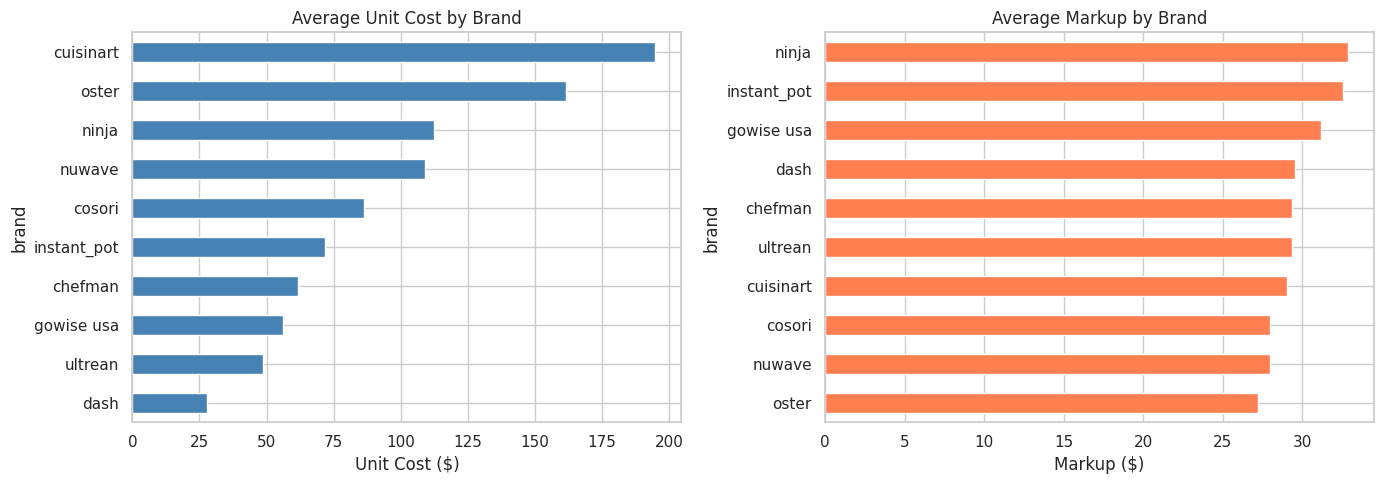

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_summary['unit_cost'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Average Unit Cost by Brand')
axes[0].set_xlabel('Unit Cost ($)')

brand_summary['markup'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral'
)
axes[1].set_title('Average Markup by Brand')
axes[1].set_xlabel('Markup ($)')

plt.tight_layout()
plt.show()

## Question 1
By unit costs, Cuisinart is by far the most expensive to produce at ~$195, followed by Oster (160) and Ninja/Nuwave (110). The budget end is Dash (25), Ultrean (48), and Gowise USA (55).
Markups range only from about 28 (Oster) to 33 (Ninja/Instant Pot).

In [11]:
#Question 2
neg_cost = df[df['unit_cost'] < 0][['brand', 'year', 'avg_price', 'brand_share', 'unit_cost', 'markup']]

if neg_cost.empty:
    print('No negative unit costs.')
else:
    print(f'{len(neg_cost)} brand-year(s) with negative unit costs:')
    print(neg_cost.to_string(index=False))

No negative unit costs.


## Question 2
No inferred unit costs are negative in this dataset. This is a good sign because it means the model is well-behaved across all 50 brand-years.

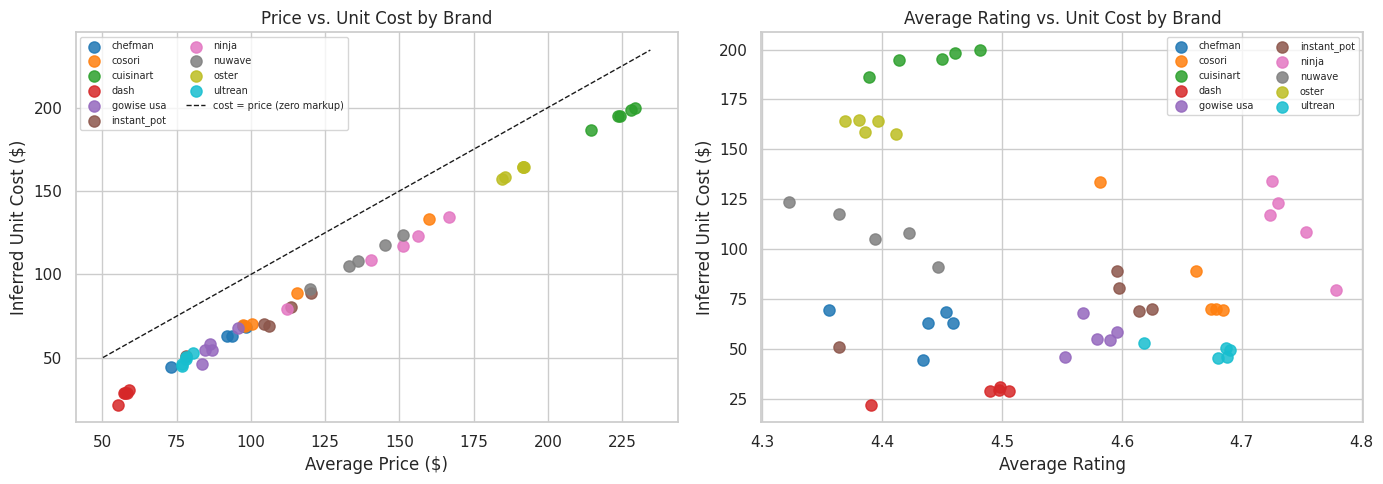

In [12]:
#Question 3
brands = sorted(df['brand'].unique())
palette = sns.color_palette('tab10', n_colors=len(brands))
color_map = dict(zip(brands, palette))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Price vs Unit Cost ---
for brand, grp in df.groupby('brand'):
    axes[0].scatter(grp['avg_price'], grp['unit_cost'],
                    label=brand, color=color_map[brand], alpha=0.85, s=65)

lims = [df['avg_price'].min() - 5, df['avg_price'].max() + 5]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='cost = price (zero markup)')
axes[0].set_xlabel('Average Price ($)')
axes[0].set_ylabel('Inferred Unit Cost ($)')
axes[0].set_title('Price vs. Unit Cost by Brand')
axes[0].legend(fontsize=7, ncol=2)

# --- Rating vs Unit Cost ---
for brand, grp in df.groupby('brand'):
    axes[1].scatter(grp['avg_rating'], grp['unit_cost'],
                    label=brand, color=color_map[brand], alpha=0.85, s=65)

axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Inferred Unit Cost ($)')
axes[1].set_title('Average Rating vs. Unit Cost by Brand')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

##Question 3
For price v unit cost, all points fall below the dashed line, confirming positive markups for every brand-year. Cuisinart clusters in the top right (195–230) and Oster in the upper middle (160–200) are the brands with the highest average cost.
For rating v unit cost, a few observations stand out: Dash (red) has the lowest unit costs but achieves ratings around 4.5, competitive with far more expensive brands. Nuwave (yellow-green) has high unit costs (160–200) but middling ratings around 4.4–4.5. Ninja (pink) sits at the high end of both cost and ratings (4.7), suggesting a genuine quality premium.

The rating vs. unit cost plot shows no clear positive trend because high cost does not reliably predict high ratings. Dash in particular is a counterexample: a very low-cost brand earning strong consumer satisfaction. The brands that rate highest (Ninja, Cosori) are not the most expensive, suggesting that consumer satisfaction in this market is driven more by product design and reliability than by price point.

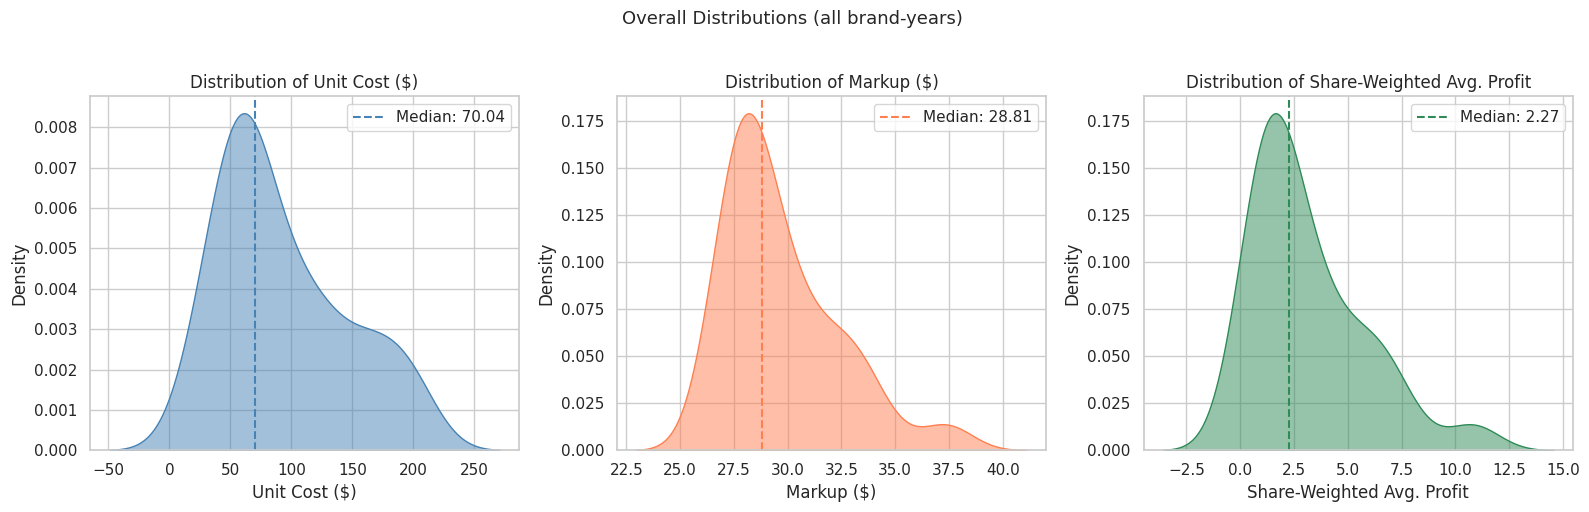

In [13]:
# Question 4
metrics = [
    ('unit_cost',      'Unit Cost ($)',                'steelblue'),
    ('markup',         'Markup ($)',                   'coral'),
    ('average_profit', 'Share-Weighted Avg. Profit',   'seagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label, color) in zip(axes, metrics):
    sns.kdeplot(df[col], ax=ax, fill=True, color=color, alpha=0.5)
    med = df[col].median()
    ax.axvline(med, color=color, linestyle='--', label=f'Median: {med:.2f}')
    ax.set_title(f'Distribution of {label}')
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle('Overall Distributions (all brand-years)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

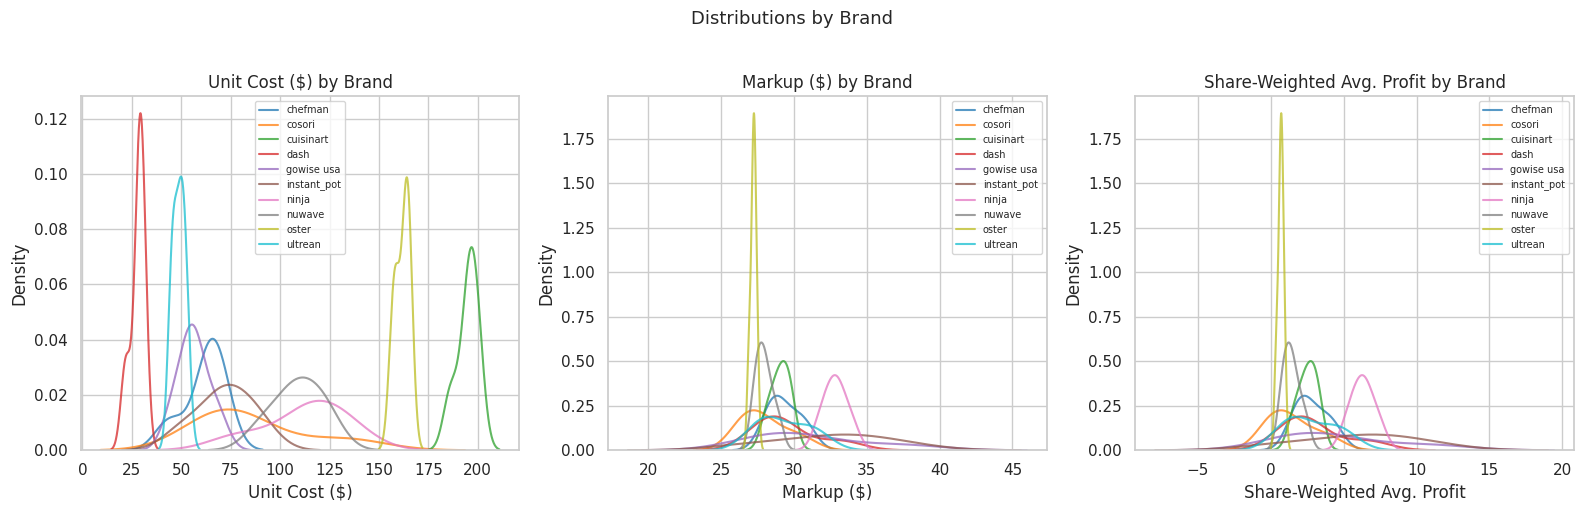

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label, _) in zip(axes, metrics):
    for brand, grp in df.groupby('brand'):
        if len(grp) > 1:
            sns.kdeplot(grp[col], ax=ax, label=brand,
                        color=color_map[brand], alpha=0.75)
    ax.set_title(f'{label} by Brand')
    ax.set_xlabel(label)
    ax.legend(fontsize=7)

plt.suptitle('Distributions by Brand', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

brand
ninja          6.3061
instant_pot    6.0103
gowise usa     4.6058
dash           2.9944
chefman        2.8210
ultrean        2.7809
cuisinart      2.5030
cosori         1.4367
nuwave         1.4229
oster          0.6783


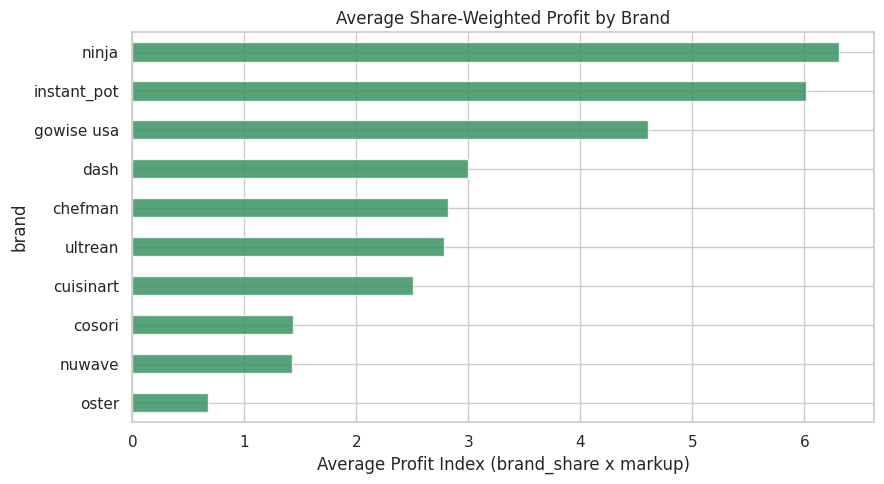

In [15]:
# Question 5
profit_by_brand = (
    df.groupby('brand')['average_profit']
    .mean()
    .sort_values(ascending=False)
    .round(4)
)
print(profit_by_brand.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
profit_by_brand.sort_values().plot(kind='barh', ax=ax, color='seagreen', alpha=0.8)
ax.set_title('Average Share-Weighted Profit by Brand')
ax.set_xlabel('Average Profit Index (brand_share x markup)')
plt.tight_layout()
plt.show()

## Question 5
Ninja and Instant Pot have the highest share-weighted average profit with profit indices of 6.31 and 6.01, respectively, followed by Gowise USA at 4.61. Then, there is a notable drop to Dash, Chefman, and Ultrean, which cluster between 2.8 and 3.0.

## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.